# クリーク被覆問題

こちらでは、[Lucas, 2014, "Ising formulations of many NP problems"](https://doi.org/10.3389/fphy.2014.00005) の 6.2. Clique Cover を OpenJij と [JijModeling](https://jij-inc-jijmodeling-tutorials-ja.readthedocs-hosted.com/ja/latest/introduction.html)、そして ommx-openjij-adapter を用いて解く方法をご紹介します。


## 概要: クリーク被覆問題

クリーク被覆問題は、あるグラフと整数$n$が与えられた時に、グラフを$n$個のクリーク（完全グラフ）に分割できるかを決定する問題です。

### 完全グラフ

完全グラフ(complete graph)とは、相異なる2点が全て隣接しているグラフ(ただしループや多重辺を含まない)構造のことです。具体的には以下のようなものを指します。

![](../../../assets/clique_cover_01.png)

完全グラフは、そこに含まれる2点を選んだときに、その2点が必ず辺で結ばれているような構造を持ちます。完全グラフの頂点数を$N$とすると、辺の数は$V$個の頂点から2つを選ぶ組合せの数${}_V C_2 = \frac{1}{2} V (V-1)$だけあることがわかります。  
完全グラフとの差が小さくなるように、最適化問題を定式化していきましょう。

### バイナリ変数

頂点$v$が$n$番目のクリークに属するとき1、そうでないとき0となるようなバイナリ変数$x_{v, n}$を定義します。

### 制約: 頂点は1つのクリークにしか所属できない

グラフを$N$個のクリークに分けることを考えると

$$
\sum_{n=0}^{N-1} x_{v, n} = 1 \quad (\forall v \in V) \tag{1}
$$

### 目的関数: 完全グラフとの差を最小にする

$n$番目のクリークに塗り分けられた部分の頂点数を$V_n (=\sum_v x_{v, n})$とすると、この頂点たちが完全グラフを形成しているならば、その辺の数は$\frac{1}{2} V_n (V_n-1)$となります。しかし、$n$番目のクリークに属する頂点が実際に形成する辺の数は、グラフの辺集合$E$を用いて$\sum_{(uv) \in E} x_{u, n} x_{v, n}$のように書かれます。この2つの差が0に近いほど、綺麗にグラフがクリークに分けれていることになります。よって目的関数は

$$
\mathrm{obj} = \sum_{n=0}^{N-1} \left\{ \frac{1}{2} \left( \sum_{v=0}^{V-1} x_{v, n}\right) \left( \sum_{v=0}^{V-1} x_{v, n}-1\right) - \sum_{(uv) \in E}x_{u, n} x_{v, n}\right\} \tag{2}
$$

## JijModelingによる定式化

次に、JijModelingを使って上記の数理モデルを定式化してみましょう。まずは、数理モデルに現れる変数およびパラメーターを定義します。

In [17]:
import jijmodeling as jm

problem = jm.Problem('Clique Cover')

V = problem.Natural('V')
E = problem.Graph('E')
N = problem.Natural('N')
x = problem.BinaryVar('x', shape=(V, N))

ここでは `V` を頂点の数、`E` をグラフ $G$ の辺集合、`N` をクリークの数として定義しており、$x_{v, n}$ に相当する2次元のバイナリ変数として `x` を定義しています。

### 制約

式(1)の制約を定式化しましょう。

In [18]:
problem += problem.Constraint('color', lambda v: jm.sum(N, lambda n: x[v, n]) == 1, domain=V)

### 目的関数
次に、式(2)の目的関数を定式化しましょう。

In [19]:
problem += jm.sum(
    N, 
    lambda n: 0.5 * jm.sum(V, lambda v: x[v, n]) * (jm.sum(V, lambda v: x[v, n])-1) - jm.sum(E, lambda e: x[e[0], n]*x[e[1], n]),
)

Jupyter Notebookで、定式化された数理モデルを表示してみましょう。

In [20]:
problem

Problem(name="Clique Cover", sense=MINIMIZE, objective=sum(N.map(lambda (n: natural): 0.5 * sum(V.map(lambda (v: natural): x[v, n])) * (sum(V.map(lambda (v: natural): x[v, n])) - 1) - sum(E.map(lambda (e: Tuple[natural, natural]): x[e[0], n] * x[e[1], n])))), constraints={color: [Constraint(name="color", , lambda v: sum(N.map(lambda (n: natural): x[v, n])) == 1, domain=set(V)),],})

## インスタンスの作成

実際にクリーク被覆を行うグラフを設定しましょう。

In [ ]:
import networkx as nx

# set the number of cliques
inst_N = 3
# set empty graph
inst_G = nx.Graph()
# add edges
inst_E = [[0, 1], [1, 2], [0, 2], 
            [3, 4], [4, 5], [5, 6], [3, 6], [3, 5], [4, 6], 
            [7, 8], [8, 9], [7, 9], 
            [1, 3], [2, 6], [5, 7], [5, 9]]
inst_G.add_edges_from(inst_E)
# get the number of nodes
inst_V = list(inst_G.nodes)
num_V = len(inst_V)
instance_data = {'N': inst_N, 'V': num_V, 'E': inst_E}

このインスタンスで設定されるグラフは、以下のようなものです。

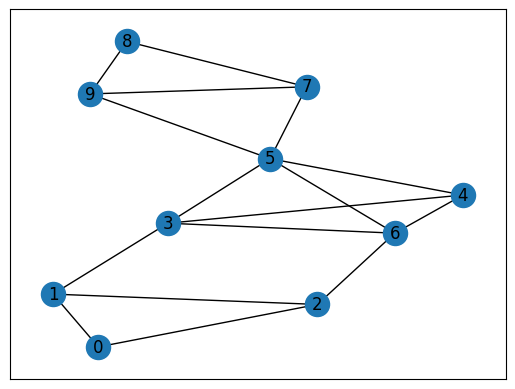

In [22]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(inst_G)
nx.draw_networkx(inst_G, pos=pos, with_labels=True)
plt.show()

{0, 1, 2}, {3, 4, 5, 6}, {7, 8, 9}の3つのクリークから成るこのグラフが、実際にクリークに分けられるかを確認してみましょう。

## OpenJijによる最適化計算の実行

OpenJijのシミュレーテッド・アニーリングを用いて、最適化問題を解いてみましょう。

In [23]:
from ommx_openjij_adapter import OMMXOpenJijSAAdapter

instance = problem.eval(instance_data)

adapter = OMMXOpenJijSAAdapter(instance)
best_sample = adapter.sample(
    instance, num_reads=100, uniform_penalty_weight=1.1
).best_feasible_unrelaxed

## 解の可視化

最後に、得られた解を可視化しましょう。

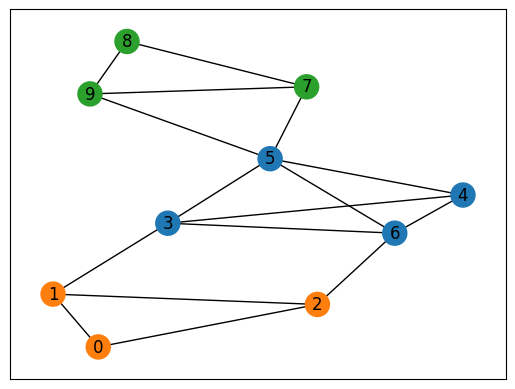

In [24]:
df = best_sample.decision_variables_df
x_indices = df[df["value"]==1.0]["subscripts"]
# initialize vertex color list
node_colors = [-1] * len(x_indices)
# set color list for visualization
cmap = plt.get_cmap("tab10")
colorlist = [cmap(i) for i in range(inst_N)]
# set vertex color list
for i, j in x_indices:
    node_colors[i] = colorlist[j]
# make figure
nx.draw_networkx(inst_G, pos=pos, node_color=node_colors, with_labels=True)
plt.show()

予想通り、OpenJijによりグラフを3つのクリークに分割することができました。